<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/article4_config_A_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Config A — Détection seule
## Pipeline :
1. **CASIA-B** : CNN+LSTM → apprend la marche normale (pré-entraînement)
2. **Transfer** : poids LSTM → direction forward du BiLSTM
3. **Le2i** : fine-tuning détection des chutes
4. **Sauvegarde** `split_info.pkl` → Notebook B utilise le même split
5. **Sauvegarde** `results_A.pkl` → Notebook B affiche la comparaison

In [1]:
# CELL 1 — Imports + Seeds
import os, pickle, cv2, math, random, gc, subprocess, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import f1_score, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Seeds | {torch.__version__} | {DEVICE}')

✅ Seeds | 2.11.0+cu128 | cuda


In [2]:
# CELL 2 — Constantes
WINDOW_SIZE     = 30
PREDICT_STEPS   = 8
STRIDE_CASIA    = 5
STRIDE_FALL     = 1    # stride=1 pour FALL → plus de fenêtres FALL
STRIDE_ADL      = 5
FPS_EXTRACT     = 10
FPS_ORIG        = 25
FPS_LE2I        = 25
N_JOINTS        = 17
INPUT_DIM       = 34
PRE_FALL_FRAMES = 20

def extract_features(kp_seq):
    xy         = kp_seq[:,:,:2].copy().astype(np.float32)
    hip_center = (xy[:,11,:]+xy[:,12,:])/2.0
    rel        = xy - hip_center[:,np.newaxis,:]
    torso_h    = np.linalg.norm(xy[:,0,:]-hip_center,axis=1,keepdims=True)
    torso_h    = np.where(torso_h<1e-6,1.0,torso_h)
    return (rel/torso_h[:,np.newaxis,:]).reshape(len(kp_seq),-1).astype(np.float32)

print(f'✅ WINDOW={WINDOW_SIZE} | STRIDE_FALL={STRIDE_FALL} | PRE_FALL={PRE_FALL_FRAMES}')

✅ WINDOW=30 | STRIDE_FALL=1 | PRE_FALL=20


In [3]:
# CELL 3 — Download datasets
!pip install kagglehub mediapipe --quiet
!apt-get install -y ffmpeg > /dev/null 2>&1

import kagglehub
path_casia = kagglehub.dataset_download('mireillejabbour/casia-b-simcc')
path_le2i  = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')
print(f'✅ CASIA : {path_casia}')
print(f'✅ Le2i  : {path_le2i}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 15.2 MB/s eta 0:00:00


100%|██████████| 230M/230M [00:01<00:00, 147MB/s]

Extracting files...


100%|██████████| 9.37G/9.37G [01:41<00:00, 99.1MB/s]

Extracting files...


✅ CASIA : /root/.cache/kagglehub/datasets/mireillejabbour/casia-b-simcc/versions/1
✅ Le2i  : /root/.cache/kagglehub/datasets/tuyenldvn/falldataset-imvia/versions/2


In [4]:
# CELL 4 — Chargement CASIA-B
def load_casia_b(root_path, conditions=['nm']):
    root = Path(root_path)/'CASIA-B_SimCC'
    sequences, skipped = [], 0
    for fp in tqdm(sorted(root.rglob('*.pkl')), desc='CASIA'):
        parts = fp.relative_to(root).parts
        if len(parts)<4: skipped+=1; continue
        cond = parts[1].split('-')[0]
        if conditions and cond not in conditions: continue
        try:
            with open(fp,'rb') as f: data=pickle.load(f)
            if not isinstance(data,np.ndarray): data=np.array(data,dtype=np.float32)
            if data.ndim!=3 or data.shape[1]!=17 or len(data)<25: skipped+=1; continue
            sequences.append(data.astype(np.float32))
        except: skipped+=1
    print(f'✅ CASIA : {len(sequences)} séquences | {skipped} ignorées')
    return sequences

def build_casia_windows(sequences):
    X_list, Y_list = [], []
    for seq in tqdm(sequences, desc='Windows CASIA'):
        feats=extract_features(seq); T=len(feats)
        if T<WINDOW_SIZE+PREDICT_STEPS: continue
        for s in range(0,T-WINDOW_SIZE-PREDICT_STEPS+1,STRIDE_CASIA):
            e=s+WINDOW_SIZE
            X_list.append(feats[s:e]); Y_list.append(feats[e:e+PREDICT_STEPS])
    X=np.array(X_list,dtype=np.float32); Y=np.array(Y_list,dtype=np.float32)
    print(f'✅ CASIA : X={X.shape} | Y={Y.shape}'); return X,Y

sequences_casia  = load_casia_b(path_casia, conditions=['nm'])
X_casia, Y_casia = build_casia_windows(sequences_casia)

CASIA: 100%|██████████| 13640/13640 [00:06<00:00, 2092.01it/s]


✅ CASIA : 8175 séquences | 9 ignorées


Windows CASIA: 100%|██████████| 8175/8175 [00:02<00:00, 2769.12it/s]


✅ CASIA : X=(107489, 30, 34) | Y=(107489, 8, 34)


In [5]:
# CELL 5 — CNN+LSTM pre-training sur CASIA-B
# CNN  : extrait les features spatiales de chaque frame
#        34 dims → 128 → 64 (linear layers, appliqués par frame)
# LSTM : modélise la dynamique temporelle de la marche
# Tâche : prédire les 8 prochaines frames → apprend la marche normale

class CASIAAnticipator(nn.Module):
    def __init__(self, input_size=34, cnn_out=64, hidden_size=256,
                 num_layers=2, predict_steps=PREDICT_STEPS, dropout=0.3):
        super().__init__()
        self.predict_steps = predict_steps
        # CNN per-frame : 34 → 128 → 64
        self.cnn = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, cnn_out),    nn.ReLU()
        )
        # LSTM : modélise la dynamique temporelle
        self.lstm = nn.LSTM(
            input_size=cnn_out, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers>1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, input_size * predict_steps)
        )
        for name, p in self.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)

    def forward(self, x):
        B,T,D = x.shape
        h = self.cnn(x.reshape(B*T,D)).reshape(B,T,-1)  # CNN per-frame
        h, _ = self.lstm(h)                               # LSTM
        return self.fc(self.dropout(h[:,-1,:])).view(B,self.predict_steps,-1)

torch.manual_seed(SEED)
model_casia = CASIAAnticipator().to(DEVICE)
print(f'✅ CASIAAnticipator : {sum(p.numel() for p in model_casia.parameters()):,} params')

class GaitDS(Dataset):
    def __init__(self,X,Y): self.X=torch.from_numpy(X); self.Y=torch.from_numpy(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.Y[i]

n_val_c=int(0.2*len(X_casia)); ds_c=GaitDS(X_casia,Y_casia)
tr_c  =Subset(ds_c,list(range(len(X_casia)-n_val_c)))
va_c  =Subset(ds_c,list(range(len(X_casia)-n_val_c,len(X_casia))))
tr_c_ld=DataLoader(tr_c,batch_size=256,shuffle=True, num_workers=2)
va_c_ld=DataLoader(va_c,batch_size=256,shuffle=False,num_workers=2)

crit_mse=nn.MSELoss()
opt_c   =torch.optim.Adam(model_casia.parameters(),lr=1e-3,weight_decay=1e-4)
sch_c   =torch.optim.lr_scheduler.ReduceLROnPlateau(opt_c,'min',patience=5,factor=0.5)
best_mse=float('inf')

print('🚀 CNN+LSTM pre-training CASIA-B — 80 epochs')
for epoch in range(1,81):
    model_casia.train(); tl=0.0
    for xb,yb in tr_c_ld:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        opt_c.zero_grad(); loss=crit_mse(model_casia(xb),yb)
        loss.backward(); nn.utils.clip_grad_norm_(model_casia.parameters(),1.0)
        opt_c.step(); tl+=loss.item()
    model_casia.eval(); vl=0.0
    with torch.no_grad():
        for xb,yb in va_c_ld:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); vl+=crit_mse(model_casia(xb),yb).item()
    tl/=len(tr_c_ld); vl/=len(va_c_ld); sch_c.step(vl)
    if vl<best_mse:
        best_mse=vl; torch.save(model_casia.state_dict(),'/content/casia_best.pth')
    if epoch%10==0 or epoch==1:
        print(f'  Ep {epoch:03d} | Train={tl:.5f} | Val={vl:.5f}')

model_casia.load_state_dict(
    torch.load('/content/casia_best.pth',map_location=DEVICE,weights_only=False))
print(f'✅ Best Val MSE = {best_mse:.6f}')

✅ CASIAAnticipator : 1,004,496 params
🚀 CNN+LSTM pre-training CASIA-B — 80 epochs
  Ep 001 | Train=0.05316 | Val=0.05559
  Ep 010 | Train=0.02948 | Val=0.04192
  Ep 020 | Train=0.02920 | Val=0.04182
  Ep 030 | Train=0.02917 | Val=0.04173
  Ep 040 | Train=0.02910 | Val=0.04167
  Ep 050 | Train=0.02905 | Val=0.04169
  Ep 060 | Train=0.02905 | Val=0.04166
  Ep 070 | Train=0.02904 | Val=0.04166
  Ep 080 | Train=0.02904 | Val=0.04167
✅ Best Val MSE = 0.041640


In [6]:
# CELL 6 — Architecture Multi-Scale CNN-BiLSTM + Config A model

class MultiScaleCNNBiLSTM(nn.Module):
    """
    Encodeur multi-échelle :
    - CNN kernel=3  : patterns locaux (impact)
    - CNN kernel=7  : transitions courtes
    - CNN kernel=15 : patterns longs (pré-chute)
    - BiLSTM : dynamique temporelle bidirectionnelle
    """
    def __init__(self, input_dim=34, lstm_h=256, dropout=0.3):
        super().__init__()
        ch = 64
        self.cnn3  = nn.Sequential(nn.Conv1d(input_dim,ch,3,padding=1), nn.BatchNorm1d(ch),nn.ReLU())
        self.cnn7  = nn.Sequential(nn.Conv1d(input_dim,ch,7,padding=3), nn.BatchNorm1d(ch),nn.ReLU())
        self.cnn15 = nn.Sequential(nn.Conv1d(input_dim,ch,15,padding=7),nn.BatchNorm1d(ch),nn.ReLU())
        self.fusion= nn.Sequential(nn.Conv1d(ch*3,128,1),nn.BatchNorm1d(128),nn.ReLU())
        self.bilstm= nn.LSTM(128,lstm_h,2,batch_first=True,bidirectional=True,dropout=dropout)
        self.attn  = nn.Sequential(nn.Linear(lstm_h*2,lstm_h),nn.Tanh(),nn.Linear(lstm_h,1))
        self.drop  = nn.Dropout(dropout)
        self.out_dim = lstm_h*2  # 512

    def forward(self, x):
        xT = x.permute(0,2,1)
        h  = self.fusion(torch.cat([self.cnn3(xT),self.cnn7(xT),self.cnn15(xT)],dim=1))
        h, _ = self.bilstm(h.permute(0,2,1))
        h  = self.drop(h)
        w  = torch.softmax(self.attn(h),dim=1)
        return (w*h).sum(dim=1)  # (B, 512)

class DetectionOnlyModel(nn.Module):
    """Config A : z(512) → det_head → NON-FALL/FALL"""
    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder  = MultiScaleCNNBiLSTM(dropout=dropout)
        self.det_head = nn.Sequential(
            nn.Linear(512,256),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(256,128),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(128,2))
    def forward(self,x): return self.det_head(self.encoder(x))

print('✅ MultiScaleCNNBiLSTM + DetectionOnlyModel définis')

✅ MultiScaleCNNBiLSTM + DetectionOnlyModel définis


In [7]:
# CELL 7 — Transfer LSTM(CASIA) → BiLSTM(encodeur)
# Transfère les poids hidden-to-hidden et biases
# LSTM hidden=256, BiLSTM hidden=256 → même shape → transfer parfait

def transfer_lstm_to_bilstm(casia_model, bilstm_module):
    src = casia_model.lstm.state_dict()
    dst = bilstm_module.state_dict()
    transferred = 0
    for layer in range(2):
        for wtype in ['weight_hh','bias_ih','bias_hh']:
            sk = f'{wtype}_l{layer}'
            dk = f'{wtype}_l{layer}'  # direction forward
            if sk not in src or dk not in dst: continue
            sw=src[sk]; dw=dst[dk].clone()
            if sw.dim()==2:
                nr=min(sw.shape[0],dw.shape[0]); nc=min(sw.shape[1],dw.shape[1])
                dw[:nr,:nc]=sw[:nr,:nc]
            else:
                n=min(sw.shape[0],dw.shape[0]); dw[:n]=sw[:n]
            dst[dk]=dw; transferred+=1
    bilstm_module.load_state_dict(dst)
    print(f'✅ Transfer LSTM→BiLSTM : {transferred} tenseurs (direction forward)')
    return bilstm_module

print('✅ transfer_lstm_to_bilstm définie')

✅ transfer_lstm_to_bilstm définie


In [8]:
from google.colab import files
uploaded = files.upload()

Saving le2i_data.pkl to le2i_data.pkl
Saving split_info.pkl to split_info.pkl


In [9]:
# CELL 8 — Chargement Le2i + Split + Fenêtres
# SAUVEGARDE split_info.pkl → Notebook B utilise le même split !
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request

SAVE_PATH  = '/content/le2i_data.pkl'
MP_TO_COCO = [0,2,5,7,8,11,12,13,14,15,16,23,24,25,26,27,28]

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH,'rb') as f: labeled_data=pickle.load(f)
    for d in labeled_data: d['keypoints']=d['keypoints'].astype(np.float32)
    fall_n=sum(1 for d in labeled_data if d['is_fall'])
    print(f'✅ Le2i : {len(labeled_data)} séquences | Fall={fall_n} | ADL={len(labeled_data)-fall_n}')
else:
    MODEL_PATH='/content/pose_landmarker.task'
    if not os.path.exists(MODEL_PATH):
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/mediapipe-models/pose_landmarker/'
            'pose_landmarker_lite/float16/latest/pose_landmarker_lite.task',MODEL_PATH)
    root=Path(path_le2i)
    def read_ann(tp):
        for enc in ['utf-8','latin-1','cp1252']:
            try:
                with open(tp,'r',encoding=enc) as f: lines=[l.strip() for l in f if l.strip()]
                if not lines: return None,None
                l1=lines[0]; l2=lines[1] if len(lines)>1 else '0'
                if ',' in l1: return 'ADL',None
                try: fs=int(l1)
                except: return None,None
                if fs==0: return 'ADL',None
                try: fe=int(l2)
                except: return 'ADL',None
                return ('FALL',(fs,fe)) if fe>fs else ('ADL',None)
            except: continue
        return None,None
    def find_txt(vp):
        pd_=vp.parent.parent; tn=vp.stem+'.txt'
        for af in ['Annotation_files','Annotations_files']:
            tp=pd_/af/tn
            if tp.exists(): return tp
        for tp in pd_.rglob(tn): return tp
        return None
    all_v=sorted(list(root.rglob('*.avi'))+list(root.rglob('*.AVI')))
    fall_list,adl_list=[],[]
    for v in all_v:
        rl=str(v.relative_to(root)).lower()
        if any(k in rl for k in ['lecture','office']): continue
        tp=find_txt(v)
        if tp is None: continue
        lbl,ann=read_ann(tp)
        if lbl=='FALL': fall_list.append((v,ann[0],ann[1]))
        elif lbl=='ADL': adl_list.append(v)
    fd=[(vp,fs,fe,cv2.VideoCapture(str(vp)).get(cv2.CAP_PROP_FRAME_COUNT)) for vp,fs,fe in fall_list]
    fd.sort(key=lambda x:x[3],reverse=True); fall_list=[(v,fs,fe) for v,fs,fe,_ in fd[:93]]
    opts=mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        num_poses=1,min_pose_detection_confidence=0.1,
        min_pose_presence_confidence=0.1,min_tracking_confidence=0.1,
        running_mode=mp_vision.RunningMode.IMAGE)
    detector=mp_vision.PoseLandmarker.create_from_options(opts)
    zeros_kp=np.zeros((17,2),dtype=np.float32)
    result=[]; stats={'fall':0,'adl':0,'skip':0}
    tmp_dir='/content/tmp_frames'
    def extract_kp(frame_bgr):
        try:
            if frame_bgr is None or frame_bgr.size==0: return None
            img=(cv2.cvtColor(frame_bgr,cv2.COLOR_GRAY2RGB) if len(frame_bgr.shape)==2
                 else cv2.cvtColor(frame_bgr,cv2.COLOR_BGR2RGB))
            h,w=img.shape[:2]
            if h<10 or w<10: return None
            res=detector.detect(mp.Image(image_format=mp.ImageFormat.SRGB,data=img))
            if not res.pose_landmarks: return None
            lms=res.pose_landmarks[0]; kp=np.zeros((17,2),dtype=np.float32)
            for ci,mi in enumerate(MP_TO_COCO): kp[ci,0]=lms[mi].x*w; kp[ci,1]=lms[mi].y*h
            return kp
        except: return None
    def proc_vid(vpath):
        if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir)
        os.makedirs(tmp_dir)
        subprocess.run(['ffmpeg','-i',str(vpath),'-vf',f'fps={FPS_EXTRACT}',
            '-q:v','2','-loglevel','error',f'{tmp_dir}/frame_%04d.png'],
            timeout=60,capture_output=True,check=False)
        frames=sorted(Path(tmp_dir).glob('frame_*.png'))
        if len(frames)<WINDOW_SIZE: return None
        kp_l=[]
        for fp in frames:
            fr=cv2.imread(str(fp)); kp=extract_kp(fr)
            kp_l.append(kp if kp is not None else zeros_kp.copy()); del fr
        return np.stack(kp_l).astype(np.float16) if len(kp_l)>=WINDOW_SIZE else None
    def assign_lbl(T,fs_o,fe_o):
        r=FPS_EXTRACT/FPS_ORIG; fs=min(int(round(fs_o*r)),T-1); fe=min(int(round(fe_o*r)),T-1)
        ps=max(0,fs-PRE_FALL_FRAMES)
        ant=np.zeros(T,dtype=np.int64); det=np.zeros(T,dtype=np.int64)
        det[fs:fe+1]=1; ant[ps:fs]=1; ant[fs:]=-1; return ant,det
    for vp,fs,fe in tqdm(fall_list,desc='FALL'):
        try:
            ks=proc_vid(vp)
            if ks is None: stats['skip']+=1; continue
            ant,det=assign_lbl(len(ks),fs,fe)
            result.append({'keypoints':ks,'labels_ant':ant,'labels_det':det,
                           'seq_name':vp.stem,'is_fall':True,'fall_start':fs,'fall_end':fe})
            stats['fall']+=1
        except: stats['skip']+=1
        finally: gc.collect()
    for vp in tqdm(adl_list,desc='ADL'):
        try:
            ks=proc_vid(vp)
            if ks is None: stats['skip']+=1; continue
            T=len(ks)
            result.append({'keypoints':ks,'labels_ant':np.zeros(T,dtype=np.int64),
                           'labels_det':np.zeros(T,dtype=np.int64),
                           'seq_name':vp.stem,'is_fall':False,'fall_start':None,'fall_end':None})
            stats['adl']+=1
        except: stats['skip']+=1
        finally: gc.collect()
    detector.close()
    if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir)
    with open(SAVE_PATH,'wb') as f: pickle.dump(result,f)
    labeled_data=result
    for d in labeled_data: d['keypoints']=d['keypoints'].astype(np.float32)
    print(f'✅ Fall={stats["fall"]} | ADL={stats["adl"]} | Skip={stats["skip"]}')

# ── Split par vidéo 70/15/15 (SOURCE DE VÉRITÉ — Config B doit reproduire EXACTEMENT cette logique) ──
# Si split_info.pkl existe déjà (ex: transféré depuis une session Config B précédente),
# on le RÉUTILISE tel quel — on ne régénère JAMAIS un split par-dessus un split existant.
# C'est ce qui garantit A et B identiques même si les deux notebooks tournent des
# jours différents, dans des runtimes/sessions Colab ou Kaggle séparés.
SPLIT_PKL = '/content/split_info.pkl'

if os.path.exists(SPLIT_PKL):
    with open(SPLIT_PKL, 'rb') as f: split_info = pickle.load(f)
    print(f'✅ split_info.pkl déjà présent (SEED={split_info["seed"]}) → RÉUTILISÉ tel quel (pas de régénération)')
    train_names = set(split_info['train_names'])
    val_names   = set(split_info['val_names'])
    test_names  = set(split_info['test_names'])
    train_seqs = [d for d in labeled_data if d['seq_name'] in train_names]
    val_seqs   = [d for d in labeled_data if d['seq_name'] in val_names]
    test_seqs  = [d for d in labeled_data if d['seq_name'] in test_names]
else:
    print(f'⚠️  {SPLIT_PKL} absent → génération d\'un NOUVEAU split (70/15/15, per-video, SEED-fixed)')
    # Reseed local juste avant le split : garantit un résultat reproductible et identique
    # entre Config A et Config B, peu importe ce qui a tourné avant dans le notebook.
    random.seed(SEED); np.random.seed(SEED)
    fall_seqs=[d for d in labeled_data if d['is_fall']]
    adl_seqs =[d for d in labeled_data if not d['is_fall']]
    random.shuffle(fall_seqs); random.shuffle(adl_seqs)

    def split3(seqs,v=0.15,t=0.15):
        n=len(seqs); nt=max(1,int(round(t*n))); nv=max(1,int(round(v*n)))
        while nt+nv>=n and nv>1: nv-=1
        while nt+nv>=n and nt>1: nt-=1
        return seqs[nt+nv:],seqs[nt:nt+nv],seqs[:nt]

    fall_tr,fall_va,fall_te=split3(fall_seqs)
    adl_tr, adl_va, adl_te =split3(adl_seqs)
    train_seqs=fall_tr+adl_tr; val_seqs=fall_va+adl_va; test_seqs=fall_te+adl_te
    random.shuffle(train_seqs); random.shuffle(val_seqs); random.shuffle(test_seqs)

    # ── SAUVEGARDE split_info.pkl → Notebook B DOIT charger ce fichier ──
    split_info={'train_names':[s['seq_name'] for s in train_seqs],
                'val_names'  :[s['seq_name'] for s in val_seqs],
                'test_names' :[s['seq_name'] for s in test_seqs],'seed':SEED}
    with open(SPLIT_PKL,'wb') as f: pickle.dump(split_info,f)
    print('✅ split_info.pkl généré et sauvegardé → à transférer vers Config B si besoin')

print('\n✅ Split :')
for name,seqs in [('Train',train_seqs),('Val',val_seqs),('Test',test_seqs)]:
    nf=sum(1 for s in seqs if s['is_fall']); na=len(seqs)-nf
    print(f'   {name:5}: {nf} FALL + {na} ADL = {len(seqs)}')

# ── Fenêtres ─────────────────────────────────────────────────
def build_windows(seqs):
    X_l,ya_l,yd_l=[],[],[]
    for s in seqs:
        kp=s['keypoints'];la=s['labels_ant'];ld=s['labels_det'];T=len(kp)
        if T<WINDOW_SIZE: continue
        feats=extract_features(kp)
        stride=STRIDE_FALL if s['is_fall'] else STRIDE_ADL
        for st in range(0,T-WINDOW_SIZE+1,stride):
            en=st+WINDOW_SIZE
            X_l.append(feats[st:en]); ya_l.append(int(la[en-1])); yd_l.append(int(ld[en-1]))
    if not X_l: return (np.zeros((0,WINDOW_SIZE,INPUT_DIM),dtype=np.float32),
                        np.zeros(0,dtype=np.int64),np.zeros(0,dtype=np.int64))
    return np.array(X_l,dtype=np.float32),np.array(ya_l,dtype=np.int64),np.array(yd_l,dtype=np.int64)

X_tr,ya_tr,yd_tr=build_windows(train_seqs)
X_va,ya_va,yd_va=build_windows(val_seqs)
X_te,ya_te,yd_te=build_windows(test_seqs)

print(f'\nFenêtres Train:{len(X_tr):,} | Val:{len(X_va):,} | Test:{len(X_te):,}')
for name,yd in [('Train',yd_tr),('Val',yd_va),('Test',yd_te)]:
    f=(yd==1).sum(); nf=(yd==0).sum()
    print(f'   {name:5}: FALL={f:,} | NON-FALL={nf:,}')

# Équilibrage 5:1 sur TRAIN
np.random.seed(SEED)
idx_f=np.where(yd_tr==1)[0]; idx_nf=np.where(yd_tr==0)[0]
n_nf=min(len(idx_nf),5*len(idx_f))
idx_nf_s=np.random.choice(idx_nf,n_nf,replace=False)
idx=np.random.permutation(np.concatenate([idx_f,idx_nf_s]))
X_tr=X_tr[idx]; ya_tr=ya_tr[idx]; yd_tr=yd_tr[idx]
print(f'\n✅ Train équilibré : FALL={(yd_tr==1).sum():,} | NON-FALL={(yd_tr==0).sum():,}')

class FallDS(Dataset):
    def __init__(self,X,ya,yd):
        self.X=torch.from_numpy(X);self.ya=torch.from_numpy(ya);self.yd=torch.from_numpy(yd)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.ya[i],self.yd[i]

tr_ld =DataLoader(FallDS(X_tr,ya_tr,yd_tr),batch_size=64,shuffle=True, num_workers=2,pin_memory=True)
val_ld=DataLoader(FallDS(X_va,ya_va,yd_va),batch_size=64,shuffle=False,num_workers=2,pin_memory=True)
te_ld =DataLoader(FallDS(X_te,ya_te,yd_te),batch_size=64,shuffle=False,num_workers=2,pin_memory=True)

✅ Le2i : 127 séquences | Fall=93 | ADL=34
✅ split_info.pkl déjà présent (SEED=42) → RÉUTILISÉ tel quel (pas de régénération)

✅ Split :
   Train: 84 FALL + 27 ADL = 111
   Val  : 25 FALL + 9 ADL = 34
   Test : 25 FALL + 9 ADL = 34

Fenêtres Train:7,850 | Val:2,135 | Test:2,616
   Train: FALL=787 | NON-FALL=7,063
   Val  : FALL=231 | NON-FALL=1,904
   Test : FALL=249 | NON-FALL=2,367

✅ Train équilibré : FALL=787 | NON-FALL=3,935


In [10]:
# CELL 9 — FocalLoss + evaluate
class FocalLoss(nn.Module):
    def __init__(self,gamma=2.0,weight=None):
        super().__init__(); self.gamma=gamma; self.weight=weight
    def forward(self,logits,targets):
        ce=F.cross_entropy(logits,targets,weight=self.weight,reduction='none')
        return ((1-torch.exp(-ce))**self.gamma*ce).mean()

def compute_w(y,n):
    c=np.bincount(y[y>=0],minlength=n).astype(float); w=1./np.maximum(c,1)
    return torch.tensor(w/w.sum()*n,dtype=torch.float32)

w_det=compute_w(yd_tr,2).to(DEVICE)
print(f'✅ Poids : NON-FALL={w_det[0]:.3f} | FALL={w_det[1]:.3f}')

def evaluate(model,loader,is_B=False):
    model.eval(); p,t=[],[]
    with torch.no_grad():
        for xb,_,yd in loader:
            xb,yd=xb.to(DEVICE),yd.to(DEVICE)
            out=model(xb); ld=out[1] if is_B else out
            p.extend(ld.argmax(1).cpu().numpy()); t.extend(yd.cpu().numpy())
    p=np.array(p); t=np.array(t)
    TP=int(((p==1)&(t==1)).sum()); FP=int(((p==1)&(t==0)).sum())
    TN=int(((p==0)&(t==0)).sum()); FN=int(((p==0)&(t==1)).sum())
    f1m=f1_score(t,p,average='macro',zero_division=0)
    f1f=f1_score(t,p,pos_label=1,average='binary',zero_division=0)
    rec=TP/max(TP+FN,1); spec=TN/max(TN+FP,1); J=rec+spec-1
    return f1m,f1f,rec,np.mean(p==t),p,t,TP,FP,TN,FN,J

print('✅ evaluate définie')

✅ Poids : NON-FALL=0.333 | FALL=1.667
✅ evaluate définie


In [11]:
# CELL 10 — Entraînement Config A
print('='*62)
print('CONFIG A — CNN+LSTM(CASIA) → Transfer → BiLSTM | Détection')
print('  Phase 1 :  50 ep | BiLSTM gelé  (préserve poids CASIA)')
print('  Phase 2 : 200 ep | tout dégelé')
print('  Checkpoint : Youden J')
print('='*62)

EP1=50; EP2=200
histA,best_jA,ckpt_A=[],-float('inf'),None

torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
model_A=DetectionOnlyModel().to(DEVICE)
model_A.encoder.bilstm=transfer_lstm_to_bilstm(model_casia,model_A.encoder.bilstm)

# Phase 1 : BiLSTM gelé → CNN et det_head apprennent
for _,p in model_A.encoder.bilstm.named_parameters(): p.requires_grad=False
opt1=torch.optim.AdamW(
    filter(lambda p:p.requires_grad,model_A.parameters()),lr=1e-3,weight_decay=1e-4)
sch1=torch.optim.lr_scheduler.CosineAnnealingLR(opt1,T_max=EP1,eta_min=1e-5)
crit_A=FocalLoss(gamma=2.0,weight=w_det)

print(f'\nPHASE 1 — BiLSTM gelé ({EP1} epochs)')
for epoch in range(1,EP1+1):
    model_A.train()
    for xb,_,yd in tr_ld:
        xb,yd=xb.to(DEVICE),yd.to(DEVICE)
        opt1.zero_grad(); crit_A(model_A(xb),yd).backward()
        nn.utils.clip_grad_norm_(model_A.parameters(),1.0); opt1.step()
    sch1.step()
    if epoch%10==0 or epoch==1:
        _,f1f,rec,_,_,_,TP,FP,TN,FN,J=evaluate(model_A,val_ld)
        print(f'  Ep {epoch:03d} | F1_FALL={f1f:.4f} | TP={TP} FP={FP} TN={TN} FN={FN} | J={J:.4f}')

# Phase 2 : tout dégelé
for p in model_A.parameters(): p.requires_grad=True
opt2=torch.optim.AdamW(model_A.parameters(),lr=3e-4,weight_decay=1e-4)
sch2=torch.optim.lr_scheduler.CosineAnnealingLR(opt2,T_max=EP2,eta_min=1e-6)

print(f'\nPHASE 2 — tout dégelé ({EP2} epochs)')
for epoch in range(1,EP2+1):
    model_A.train()
    for xb,_,yd in tr_ld:
        xb,yd=xb.to(DEVICE),yd.to(DEVICE)
        opt2.zero_grad(); crit_A(model_A(xb),yd).backward()
        nn.utils.clip_grad_norm_(model_A.parameters(),1.0); opt2.step()
    sch2.step()
    f1m,f1f,rec,acc,_,_,TP,FP,TN,FN,J=evaluate(model_A,val_ld)
    if J>best_jA:
        best_jA=J
        ckpt_A={'val_f1':f1m,'val_acc':acc,'f1_fall':f1f,'recall_fall':rec,
                'tp':TP,'fp':FP,'tn':TN,'fn':FN,'j':J,
                'model_state':{k:v.clone() for k,v in model_A.state_dict().items()}}
        torch.save(ckpt_A,'/content/model_A.pth')
    histA.append({'epoch':epoch+EP1,'val_f1':f1m,'f1_fall':f1f,'recall_fall':rec,'val_acc':acc})
    if epoch%25==0 or epoch==1:
        star=' ⭐' if J==best_jA else ''
        print(f'  Ep {epoch:03d} | F1={f1m:.3f} F1_FALL={f1f:.3f} Rec={rec:.3f} | '
              f'TP={TP} FP={FP} TN={TN} FN={FN} | J={J:.4f}{star}')

# TEST FINAL
model_A.load_state_dict(
    torch.load('/content/model_A.pth',map_location=DEVICE,weights_only=False)['model_state'])
f1m,f1f,rec,acc,_,_,TP,FP,TN,FN,J=evaluate(model_A,te_ld)
ckpt_A.update({'val_f1':f1m,'val_acc':acc,'f1_fall':f1f,'recall_fall':rec,
               'tp':TP,'fp':FP,'tn':TN,'fn':FN,'j':J})

print(f'\n✅ CONFIG A — TEST FINAL :')
print(f'   F1_FALL={f1f:.4f} | Rec={rec:.4f} | Acc={acc:.4f}')
print(f'   TP={TP} | FP={FP} | TN={TN} | FN={FN} | J={J:.4f}')

# Sauvegarde pour comparaison dans Notebook B
results_A={'f1_fall':f1f,'recall':rec,'acc':acc,'f1_macro':f1m,
           'tp':TP,'fp':FP,'tn':TN,'fn':FN,'j':J}
with open('/content/results_A.pkl','wb') as f: pickle.dump(results_A,f)
print('\n✅ results_A.pkl sauvegardé → Notebook B affichera la comparaison')

CONFIG A — CNN+LSTM(CASIA) → Transfer → BiLSTM | Détection
  Phase 1 :  50 ep | BiLSTM gelé  (préserve poids CASIA)
  Phase 2 : 200 ep | tout dégelé
  Checkpoint : Youden J
✅ Transfer LSTM→BiLSTM : 6 tenseurs (direction forward)

PHASE 1 — BiLSTM gelé (50 epochs)
  Ep 001 | F1_FALL=0.3119 | TP=226 FP=992 TN=912 FN=5 | J=0.4573
  Ep 010 | F1_FALL=0.5992 | TP=216 FP=274 TN=1630 FN=15 | J=0.7912
  Ep 020 | F1_FALL=0.6470 | TP=219 FP=227 TN=1677 FN=12 | J=0.8288
  Ep 030 | F1_FALL=0.7552 | TP=216 FP=125 TN=1779 FN=15 | J=0.8694
  Ep 040 | F1_FALL=0.7606 | TP=216 FP=121 TN=1783 FN=15 | J=0.8715
  Ep 050 | F1_FALL=0.8295 | TP=214 FP=71 TN=1833 FN=17 | J=0.8891

PHASE 2 — tout dégelé (200 epochs)
  Ep 001 | F1=0.839 F1_FALL=0.723 Rec=0.939 | TP=217 FP=152 TN=1752 FN=14 | J=0.8596 ⭐
  Ep 025 | F1=0.888 F1_FALL=0.804 Rec=0.939 | TP=217 FP=92 TN=1812 FN=14 | J=0.8911
  Ep 050 | F1=0.931 F1_FALL=0.877 Rec=0.926 | TP=214 FP=43 TN=1861 FN=17 | J=0.9038
  Ep 075 | F1=0.928 F1_FALL=0.872 Rec=0.926 | 

  CONFIG A — MÉTRIQUES COMPLÈTES (TEST)

  Métrique                 NON-FALL         FALL
  ──────────────────────────────────────────────
  Precision                 0.9877       0.8462
  Recall                    0.9831       0.8835
  F1-score                  0.9854       0.8644
  ──────────────────────────────────────────────
  Accuracy                  0.9736
  Macro F1                  0.9249
  Specificity               0.9831
  Youden J                  0.8666

  TP= 220 | FP=  40 | TN= 2327 | FN=  29

  Classification Report (sklearn):
              precision    recall  f1-score   support

    NON-FALL       0.99      0.98      0.99      2367
        FALL       0.85      0.88      0.86       249

    accuracy                           0.97      2616
   macro avg       0.92      0.93      0.92      2616
weighted avg       0.97      0.97      0.97      2616



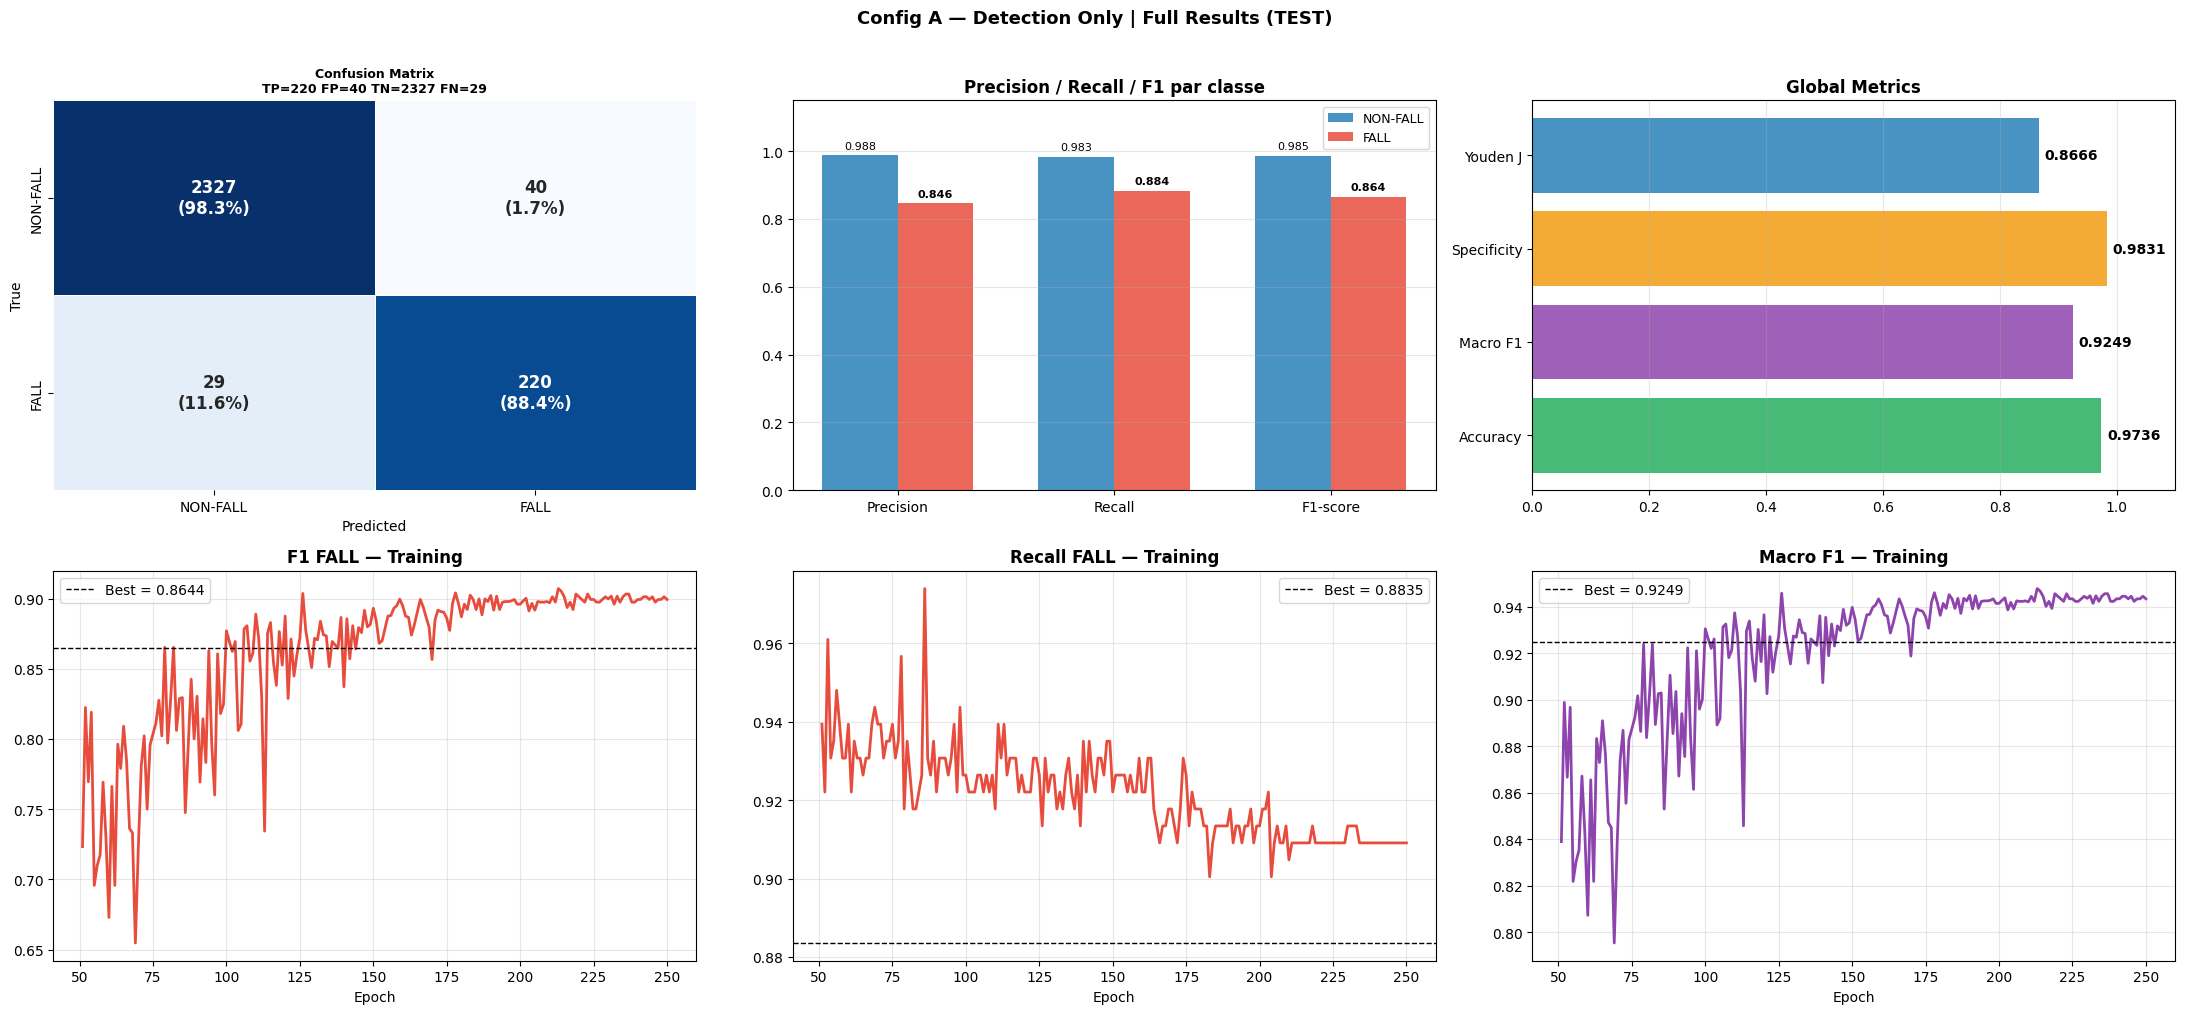

✅ /content/config_A_full_results.png

📁 Fichiers sauvegardés :
   /content/model_A.pth              → meilleur modèle
   /content/split_info.pkl           → OBLIGATOIRE pour Notebook B
   /content/results_A.pkl            → résultats pour comparaison
   /content/casia_best.pth           → poids CASIA CNN+LSTM
   /content/config_A_full_results.png → figure complète


In [12]:
# ============================================================
# CELL 11 — Rapport final Config A + Métriques complètes
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, f1_score

CLASS_NAMES = ['NON-FALL', 'FALL']

# ── Prédictions sur TEST ──────────────────────────────────────
model_A.load_state_dict(ckpt_A['model_state'])
model_A.eval()
preds_te, true_te = [], []
with torch.no_grad():
    for xb, _, yd in te_ld:
        xb = xb.to(DEVICE)
        ld  = model_A(xb)
        preds_te.extend(ld.argmax(1).cpu().numpy())
        true_te.extend(yd.numpy())

p = np.array(preds_te); t = np.array(true_te)
TP = int(((p==1)&(t==1)).sum()); FP = int(((p==1)&(t==0)).sum())
TN = int(((p==0)&(t==0)).sum()); FN = int(((p==0)&(t==1)).sum())

# ── Calcul de toutes les métriques ───────────────────────────
prec_fall  = TP / max(TP+FP, 1)
rec_fall   = TP / max(TP+FN, 1)
f1_fall    = 2*prec_fall*rec_fall / max(prec_fall+rec_fall, 1e-8)
spec       = TN / max(TN+FP, 1)
prec_nf    = TN / max(TN+FN, 1)
rec_nf     = TN / max(TN+FP, 1)
f1_nf      = 2*prec_nf*rec_nf / max(prec_nf+rec_nf, 1e-8)
acc        = (TP+TN) / max(TP+FP+TN+FN, 1)
macro_f1   = (f1_fall + f1_nf) / 2
J          = rec_fall + spec - 1

# ── Affichage métriques ───────────────────────────────────────
print('='*60)
print('  CONFIG A — MÉTRIQUES COMPLÈTES (TEST)')
print('='*60)
print(f'\n  {"Métrique":20} {"NON-FALL":>12} {"FALL":>12}')
print(f'  {"─"*46}')
print(f'  {"Precision":20} {prec_nf:>11.4f}  {prec_fall:>11.4f}')
print(f'  {"Recall":20} {rec_nf:>11.4f}  {rec_fall:>11.4f}')
print(f'  {"F1-score":20} {f1_nf:>11.4f}  {f1_fall:>11.4f}')
print(f'  {"─"*46}')
print(f'  {"Accuracy":20} {acc:>11.4f}')
print(f'  {"Macro F1":20} {macro_f1:>11.4f}')
print(f'  {"Specificity":20} {spec:>11.4f}')
print(f'  {"Youden J":20} {J:>11.4f}')
print(f'\n  TP={TP:4d} | FP={FP:4d} | TN={TN:5d} | FN={FN:4d}')
print('='*60)

# ── Rapport sklearn ───────────────────────────────────────────
print(f'\n  Classification Report (sklearn):')
print(classification_report(t, p, target_names=CLASS_NAMES, zero_division=0))

# ── Figure : 4 graphiques ────────────────────────────────────
fig = plt.figure(figsize=(22, 10))
fig.patch.set_facecolor('white')

# 1. Matrice de confusion : nombres + pourcentages
ax1 = fig.add_subplot(2, 3, 1)
total_nf   = TN + FP; total_f = TP + FN
cm_pct = np.array([
    [TN/max(total_nf,1)*100, FP/max(total_nf,1)*100],
    [FN/max(total_f,1)*100,  TP/max(total_f,1)*100]
])
ann = np.array([
    [f'{TN}\n({TN/max(total_nf,1)*100:.1f}%)', f'{FP}\n({FP/max(total_nf,1)*100:.1f}%)'],
    [f'{FN}\n({FN/max(total_f,1)*100:.1f}%)',   f'{TP}\n({TP/max(total_f,1)*100:.1f}%)']
])
sns.heatmap(cm_pct, annot=ann, fmt='', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax1, cbar=False, linewidths=0.5,
            annot_kws={'size':12, 'weight':'bold'})
ax1.set_title(f'Confusion Matrix\nTP={TP} FP={FP} TN={TN} FN={FN}',
              fontweight='bold', fontsize=9)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# 2. Barplot métriques par classe
ax2 = fig.add_subplot(2, 3, 2)
metrics_names = ['Precision', 'Recall', 'F1-score']
vals_nf  = [prec_nf,   rec_nf,  f1_nf]
vals_f   = [prec_fall, rec_fall, f1_fall]
x = np.arange(len(metrics_names)); w = 0.35
ax2.bar(x-w/2, vals_nf, w, label='NON-FALL', color='#2980B9', alpha=0.85)
ax2.bar(x+w/2, vals_f,  w, label='FALL',     color='#E74C3C', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(metrics_names, fontsize=10)
ax2.set_ylim(0, 1.15); ax2.legend(fontsize=9)
ax2.set_title('Precision / Recall / F1 par classe', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for xi,(a,b) in enumerate(zip(vals_nf,vals_f)):
    ax2.text(xi-w/2, a+0.02, f'{a:.3f}', ha='center', fontsize=8)
    ax2.text(xi+w/2, b+0.02, f'{b:.3f}', ha='center', fontsize=8, fontweight='bold')

# 3. Métriques globales
ax3 = fig.add_subplot(2, 3, 3)
glob_names = ['Accuracy', 'Macro F1', 'Specificity', 'Youden J']
glob_vals  = [acc, macro_f1, spec, J]
colors     = ['#27AE60','#8E44AD','#F39C12','#2980B9']
bars = ax3.barh(glob_names, glob_vals, color=colors, alpha=0.85)
ax3.set_xlim(0, 1.1)
ax3.set_title('Global Metrics', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, glob_vals):
    ax3.text(bar.get_width()+0.01,
             bar.get_y()+bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

# 4. Courbe F1 FALL
ax4 = fig.add_subplot(2, 3, 4)
ep = [h['epoch'] for h in histA]
ax4.plot(ep, [h['f1_fall'] for h in histA], color='#E74C3C', lw=2)
ax4.axhline(f1_fall, color='black', ls='--', lw=1,
            label=f'Best = {f1_fall:.4f}')
ax4.set_title('F1 FALL — Training', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.legend(); ax4.grid(alpha=0.3)

# 5. Courbe Recall FALL
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(ep, [h['recall_fall'] for h in histA], color='#E74C3C', lw=2)
ax5.axhline(rec_fall, color='black', ls='--', lw=1,
            label=f'Best = {rec_fall:.4f}')
ax5.set_title('Recall FALL — Training', fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.legend(); ax5.grid(alpha=0.3)

# 6. Courbe MacroF1
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(ep, [h['val_f1'] for h in histA], color='#8E44AD', lw=2)
ax6.axhline(macro_f1, color='black', ls='--', lw=1,
            label=f'Best = {macro_f1:.4f}')
ax6.set_title('Macro F1 — Training', fontweight='bold')
ax6.set_xlabel('Epoch'); ax6.legend(); ax6.grid(alpha=0.3)

plt.suptitle('Config A — Detection Only | Full Results (TEST)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/config_A_full_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ /content/config_A_full_results.png')
print(f'\n📁 Fichiers sauvegardés :')
print(f'   /content/model_A.pth              → meilleur modèle')
print(f'   /content/split_info.pkl           → OBLIGATOIRE pour Notebook B')
print(f'   /content/results_A.pkl            → résultats pour comparaison')
print(f'   /content/casia_best.pth           → poids CASIA CNN+LSTM')
print(f'   /content/config_A_full_results.png → figure complète')